In [10]:
from pathlib import Path
import matplotlib.pyplot as plt
from polytrader.data import load_history, fetch_price_history
import pandas as pd

# Works when the kernel starts in the repo root or sandbox/.
cwd = Path.cwd().resolve()
root = next((p for p in (cwd, *cwd.parents) if (p / 'src' / 'polytrader').is_dir()), None)

if root is None:
    raise RuntimeError('Start this notebook from the polytrader repository.')
root

WindowsPath('C:/Workspace/polytrader')

In [33]:
import pandas as pd
from polytrader.data import fetch_price_history, load_history

EVENT = "next-french-presidential-election"
DAYS = 30
BUCKET_SECONDS = 300

# Exact candidate portions of the slugs in your attached list.
candidates = {
    "lepen": "marine-le-pen",
    "bardella": "jordan-bardella",
    "zemmour": "ric-zemmour",
    "philippe": "douard-philippe",
    "lisnard": "david-lisnard",
    "bertrand": "xavier-bertrand",
    "wauquiez": "laurent-wauquiez",
    "ruffin": "franois-ruffin",
    "attal": "gabriel-attal",
    "retailleau": "bruno-retailleau",
    "hollande": "franois-hollande",
    "glucksmann": "raphal-glucksmann",
    "melanchon": "jean-luc-mlenchon",  # Keep your existing dictionary key.
    "tondelier": "marine-tondelier",
    "roussel": "fabien-roussel",
    "faure": "olivier-faure",
    "villepin": "dominique-de-villepin",
    "royal": "sgolne-royal",
    "asselineau": "franois-asselineau",
    "autain": "clmentine-autain",
    "dupont_aignan": "nicolas-dupont-aignan",
    "barnier": "michel-barnier",
    "pecresse": "valrie-pcresse",
    "bayrou": "franois-bayrou",
    "borne": "lisabeth-borne",
    "braun_pivet": "yal-braun-pivet",
    "castex": "jean-castex",
    "darmanin": "grald-darmanin",
    "delga": "carole-delga",
    "cazeneuve": "bernard-cazeneuve",
    "bompard": "manuel-bompard",
    "panot": "mathilde-panot",
    "other": "another-person",
    "knafo": "sarah-knafo",
    "branco": "juan-branco",
    "guette": "clmence-guett",
    "lecornu": "sbastien-lecornu",
    "bouamrane": "karim-bouamrane",
    "castets": "lucie-castets",
    "jadot": "yannick-jadot",
    "baroin": "franois-baroin",
    "marechal": "marion-marchal",
}

data_dir = root / "data"
data_dir.mkdir(parents=True, exist_ok=True)

data = {}
series = {}
failures = {}

for i, (name, slug_part) in enumerate(candidates.items(), start=1):
    slug = f"will-{slug_part}-win-the-2027-french-presidential-election"
    path = data_dir / f"{name}-history.json"

    print(f"[{i}/{len(candidates)}] {name}", end=" ... ")

    try:
        history = fetch_price_history(
            event=EVENT,
            market=slug,
            days=DAYS,
            bucket_seconds=BUCKET_SECONDS,
        )

        if not history.data:
            raise ValueError("No historical observations returned")

        # Save, then load using your existing workflow.
        history.save(path)
        loaded = load_history(path)
        df = pd.DataFrame(loaded.data)

        # Keep raw timestamps in data, as in your original notebook.
        timestamps = pd.to_datetime(df["timestamp"], unit="s", utc=True)
        values = pd.to_numeric(df["price"], errors="raise")

        s = pd.Series(
            values.to_numpy(),
            index=pd.DatetimeIndex(timestamps, name="timestamp"),
            name=name,
        ).sort_index()

        s = s.loc[~s.index.duplicated(keep="last")]

        data[name] = df
        series[name] = s

        print(f"{len(df):,} observations")

    except Exception as exc:
        # Continue downloading the other markets; report failures explicitly.
        failures[name] = str(exc)
        print(f"FAILED: {exc}")

if not series:
    raise RuntimeError(f"No histories loaded successfully: {failures}")

# Resample each market independently onto hourly intervals.
prices = pd.concat(
    {
        name: s.resample("1h", closed="right", label="right").last()
        for name, s in series.items()
    },
    axis=1,
).sort_index()

print(f"\nLoaded {len(data)}/{len(candidates)} markets")
print(prices.tail())

if failures:
    print("\nFailed markets:")
    for name, error in failures.items():
        print(f"  {name}: {error}")

[1/42] lepen ... FAILED: [Errno 17] File exists: 'C:\\Workspace\\polytrader\\data\\lepen-history.json'
[2/42] bardella ... 8,543 observations
[3/42] zemmour ... 8,613 observations
[4/42] philippe ... FAILED: [Errno 17] File exists: 'C:\\Workspace\\polytrader\\data\\philippe-history.json'
[5/42] lisnard ... FAILED: [Errno 17] File exists: 'C:\\Workspace\\polytrader\\data\\lisnard-history.json'
[6/42] bertrand ... 8,564 observations
[7/42] wauquiez ... 8,554 observations
[8/42] ruffin ... 8,562 observations
[9/42] attal ... 8,492 observations
[10/42] retailleau ... 8,539 observations
[11/42] hollande ... 8,511 observations
[12/42] glucksmann ... 8,609 observations
[13/42] melanchon ... FAILED: [Errno 17] File exists: 'C:\\Workspace\\polytrader\\data\\melanchon-history.json'
[14/42] tondelier ... 8,567 observations
[15/42] roussel ... 8,455 observations
[16/42] faure ... 8,565 observations
[17/42] villepin ... 8,559 observations
[18/42] royal ... 8,552 observations
[19/42] asselineau ... 

In [34]:
changes = prices.diff()

# Require at least 100 overlapping hourly changes per pair.
correlation = changes.corr(min_periods=100)
print(correlation.round(3))

               bardella  zemmour  bertrand  wauquiez  ruffin  attal  \
bardella          1.000    0.074    -0.000    -0.001   0.056  0.041   
zemmour           0.074    1.000     0.000     0.034   0.041  0.015   
bertrand         -0.000    0.000     1.000    -0.000   0.035 -0.050   
wauquiez         -0.001    0.034    -0.000     1.000   0.000  0.016   
ruffin            0.056    0.041     0.035     0.000   1.000 -0.025   
attal             0.041    0.015    -0.050     0.016  -0.025  1.000   
retailleau        0.009   -0.018    -0.030    -0.001  -0.032  0.039   
hollande          0.018    0.063    -0.002     0.010  -0.040  0.063   
glucksmann       -0.051    0.084     0.004     0.040   0.014  0.073   
tondelier         0.000    0.084     0.084     0.000   0.280  0.029   
roussel          -0.001    0.000    -0.000    -0.001   0.000 -0.002   
faure            -0.011   -0.164     0.000     0.013   0.004  0.013   
villepin          0.030   -0.024     0.027     0.018  -0.016  0.026   
royal 

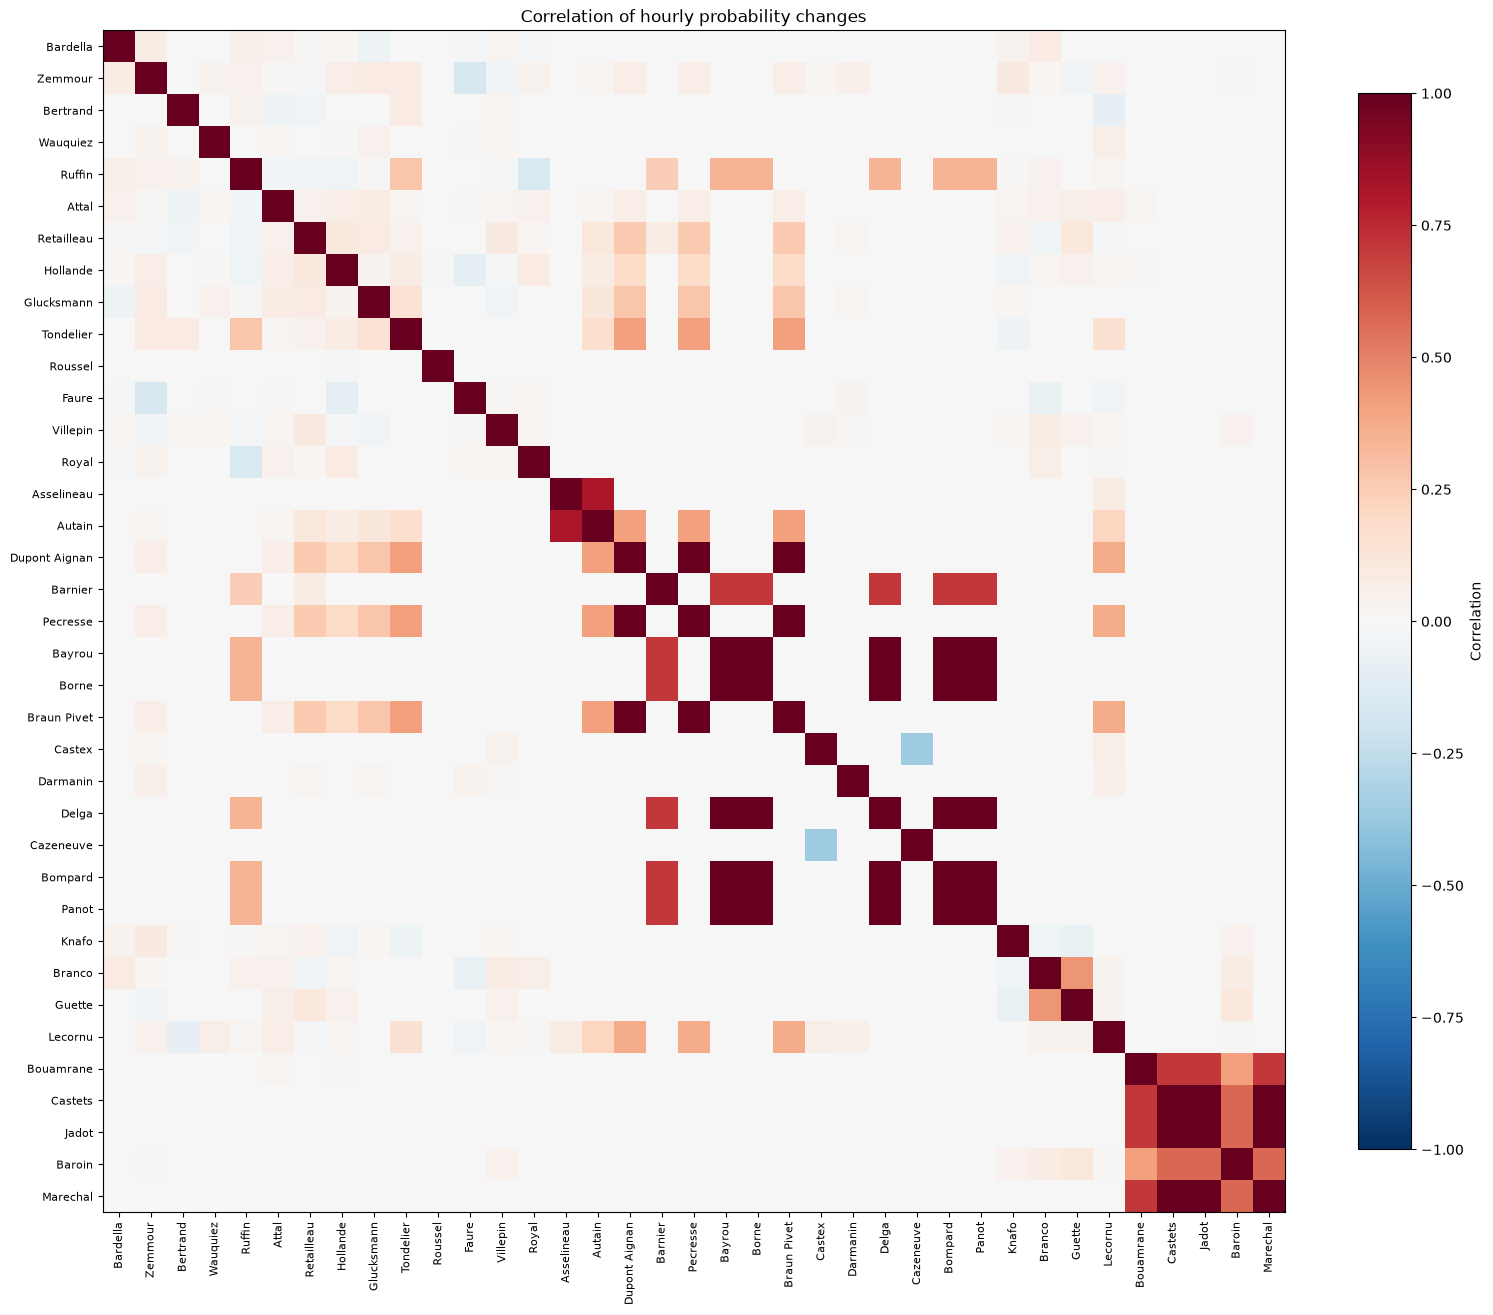

In [35]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

labels = correlation.columns.str.replace("_", " ").str.title()

fig, ax = plt.subplots(figsize=(16, 14))

cmap = plt.get_cmap("RdBu_r").copy()
cmap.set_bad("lightgrey")  # Missing correlations

im = ax.imshow(
    np.ma.masked_invalid(correlation.to_numpy()),
    cmap=cmap,
    vmin=-1,
    vmax=1,
)

ax.set_xticks(range(len(labels)), labels, rotation=90, fontsize=8)
ax.set_yticks(range(len(labels)), labels, fontsize=8)
ax.set_title("Correlation of hourly probability changes")
fig.colorbar(im, ax=ax, label="Correlation", shrink=0.8)

plt.tight_layout()
plt.show()

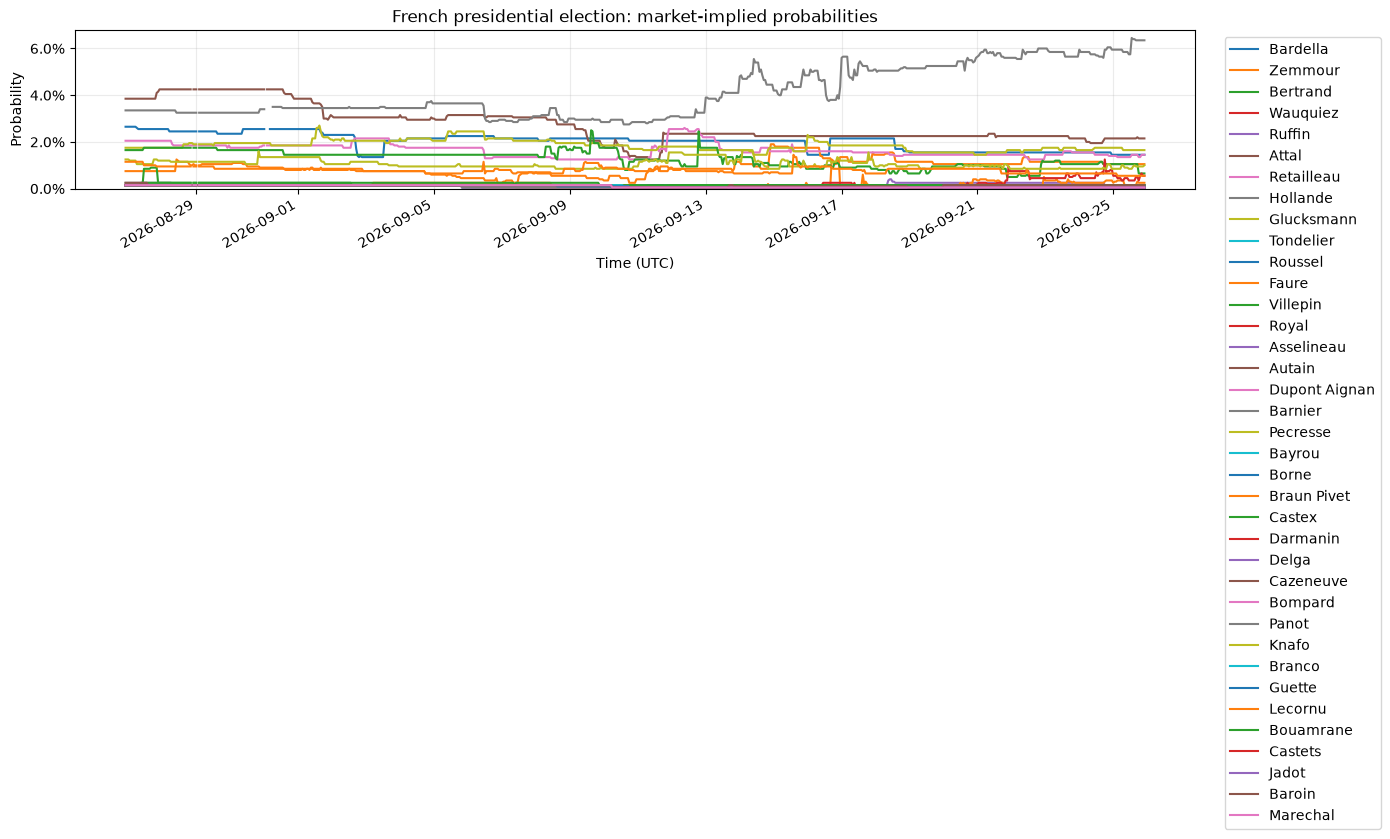

In [37]:
# Rank by each candidate's latest non-missing observation.
latest = prices.apply(
    lambda s: s.dropna().iloc[-1] if s.notna().any() else np.nan
)
selected = prices.columns

fig, ax = plt.subplots(figsize=(14, 6))

for name in selected:
    ax.plot(
        prices.index,
        prices[name],
        label=name.replace("_", " ").title(),
    )

ax.set(
    title="French presidential election: market-implied probabilities",
    xlabel="Time (UTC)",
    ylabel="Probability",
    ylim=(0, None),
)
ax.yaxis.set_major_formatter(PercentFormatter(xmax=1))
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1))
ax.grid(alpha=0.25)

fig.autofmt_xdate()
plt.tight_layout()
plt.show()